# Reading data from a file, and fitting it

The other notebooks build their data in the cell above the plot. Real work does not: the numbers come
from a file, and the figure has to survive whatever that file contains. This one reads
[`data/oscillation.dat`](data/oscillation.dat), plots it, fits a sinusoid to it, and reports how well
the fit did.

The data is synthetic — a sine with Gaussian noise, written by
[`data/make_oscillation.py`](data/make_oscillation.py) — and the axis labels are deliberately generic.
Nothing here is a measurement of anything.

In [1]:
%matplotlib inline

# Jupyter crops every inline preview with bbox_inches="tight". That defeats the exact column widths
# this package exists to guarantee, and because the themes sit the axes close to the canvas edge, the
# crop slices through the top and right spines. Turn it off so previews match the files jf.save() writes.
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}

# jf.save() reports what it wrote through the "journalfig" logger instead of printing. Raise that one
# logger -- a blanket logging.basicConfig(level="INFO") also switches on fontTools, which logs a dozen
# subsetting lines per PDF.
import logging

logging.basicConfig(format="%(message)s")
logging.getLogger("journalfig").setLevel(logging.INFO)

import numpy as np
import matplotlib.pyplot as plt

import journalfig as jf

# The themes render previews at 600 dpi, which makes every embedded image in a notebook large. This
# only touches the on-screen preview; jf.save() exports at savefig.dpi regardless.
PREVIEW_DPI = 150


def preview(journal, **kwargs):
    """Apply a theme, then drop the on-screen DPI so this notebook stays light."""
    jf.use(journal, **kwargs)
    plt.rcParams["figure.dpi"] = PREVIEW_DPI


rng = np.random.default_rng(0)
print("journalfig", jf.__version__, "| themes:", jf.JOURNALS)

journalfig 0.4.0 | themes: ('nature', 'aps', 'elsevier')


## Find the file relative to the notebook

Never hard-code an absolute path, and do not rely on the working directory: a notebook run from the
repository root and the same notebook run from its own folder disagree about what `"data/..."` means.
Resolving against the notebook's own location works in both cases.

In [2]:
from pathlib import Path

# Path.cwd() is where the kernel started, which for a notebook is the folder holding it.
DATA = Path.cwd() / "data" / "oscillation.dat"
if not DATA.exists():  # running from the repository root instead
    DATA = Path.cwd() / "examples" / "data" / "oscillation.dat"

print("reading:", DATA)
print("exists :", DATA.exists(), f"({DATA.stat().st_size / 1024:.1f} kB)")

reading: /Users/achrafatila/Documents/Workflows/plotstyles/examples/data/oscillation.dat
exists : True (2.8 kB)


## Read the header before the numbers

A data file worth keeping records where it came from. This one carries its model, its parameters and
its seed in comment lines, so the numbers below can be regenerated exactly.

In [3]:
header = [line for line in DATA.read_text().splitlines() if line.startswith("#")]
print("\n".join(header))

# Synthetic demonstration data for the journalfig example notebooks.
# Not a measurement of anything: a sinusoid plus Gaussian noise.
#
# model  : y = A * sin(2*pi*f*x + phi) + c, noise ~ Normal(0, sigma)
# params : A=2.5  f=0.35  phi=0.8  c=0.4  sigma=0.35
# seed   : numpy.random.default_rng(20260805)
# source : examples/data/oscillation.dat written by examples/data/make_oscillation.py
#
# columns below, whitespace separated: x (a.u.), y (a.u.), y_err (a.u.)
#  x  y  y_err


## Read the columns

The file is plain whitespace-separated columns with a `#` comment header — the format numpy reads with
no arguments at all. `np.loadtxt` skips `#` lines whatever their number, and `unpack=True` transposes
the result so each column arrives as its own array.

That is the whole reason to prefer this layout: no delimiter to declare, no header row to skip, no
parsing library. `np.genfromtxt` is the one to reach for when there are missing values to fill.

In [4]:
x, y, y_err = np.loadtxt(DATA, unpack=True)

print(f"{x.size} points")
print(f"x     : {x.min():.3f} to {x.max():.3f}")
print(f"y     : {y.min():.3f} to {y.max():.3f}")
print(f"y_err : {np.unique(y_err)} (constant here)")
print()
print("  x        y        y_err")
for row in zip(x[:5], y[:5], y_err[:5]):
    print("  {:7.4f}  {:7.4f}  {:.4f}".format(*row))

60 points
x     : 0.000 to 12.000
y     : -2.808 to 3.705
y_err : [0.35] (constant here)

  x        y        y_err
   0.0000   1.9206  0.3500
   0.2034   3.2547  0.3500
   0.4068   3.4381  0.3500
   0.6102   2.5546  0.3500
   0.8136   1.8102  0.3500


## Look at it before fitting anything

Plot first. A fit to data you have not looked at is a way of getting a confident wrong answer.

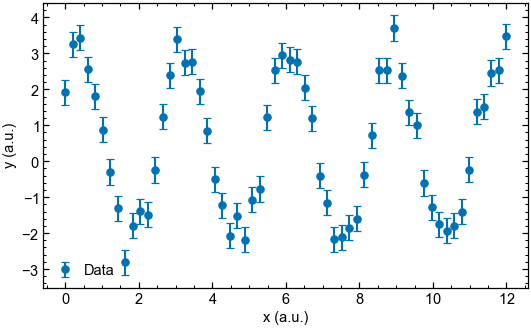

In [5]:
preview("elsevier")

fig, ax = jf.subplots("elsevier", width="single")
ax.errorbar(x, y, yerr=y_err, linestyle="none", marker="o", capsize=plt.rcParams["errorbar.capsize"],
            label="Data")
ax.set_xlabel("x (a.u.)")
ax.set_ylabel("y (a.u.)")
ax.legend()

## A model, and a starting guess that is not a guess

`curve_fit` needs initial parameters, and a sinusoid is exactly the case where bad ones send the
optimiser into a local minimum — get the frequency wrong and it happily fits a curve through the
noise. Estimate each parameter from the data instead of typing numbers:

- **offset** — the mean.
- **amplitude** — half the peak-to-peak range, or `sqrt(2)` times the standard deviation.
- **frequency** — the dominant peak of the FFT, ignoring the zero-frequency bin.
- **phase** — leave at zero; it is the one parameter the optimiser finds easily.

In [6]:
def sinusoid(x, amplitude, frequency, phase, offset):
    """A * sin(2*pi*f*x + phi) + c."""
    return amplitude * np.sin(2 * np.pi * frequency * x + phase) + offset


spectrum = np.abs(np.fft.rfft(y - y.mean()))
freqs = np.fft.rfftfreq(x.size, d=x[1] - x[0])
f0 = freqs[1:][np.argmax(spectrum[1:])]

guess = [np.sqrt(2) * y.std(), f0, 0.0, y.mean()]
print(f"amplitude guess : {guess[0]:.3f}")
print(f"frequency guess : {guess[1]:.3f}  (FFT peak)")
print(f"phase guess     : {guess[2]:.3f}")
print(f"offset guess    : {guess[3]:.3f}")

amplitude guess : 2.720
frequency guess : 0.328  (FFT peak)
phase guess     : 0.000
offset guess    : 0.549


## Fit, weighted by the uncertainties

Pass `sigma=y_err` so points with larger error bars pull less, and `absolute_sigma=True` so the
covariance matrix is scaled by the uncertainties you supplied rather than by the fit's own residual
scatter. With `absolute_sigma=False` — the default — the reported parameter errors depend on how well
the model happened to fit, which is not what you want when the measurement uncertainty is known.

In [7]:
from scipy.optimize import curve_fit

popt, pcov = curve_fit(sinusoid, x, y, p0=guess, sigma=y_err, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))

truth = {"amplitude": 2.5, "frequency": 0.35, "phase": 0.8, "offset": 0.4}
print(f"{'parameter':11s} {'fitted':>18s}   {'generated':>10s}   {'pull':>6s}")
for name, value, err in zip(truth, popt, perr):
    pull = (value - truth[name]) / err
    print(f"{name:11s} {value:8.4f} +/- {err:6.4f}   {truth[name]:10.4f}   {pull:+6.2f}")

parameter               fitted    generated     pull
amplitude     2.6387 +/- 0.0630       2.5000    +2.20
frequency     0.3496 +/- 0.0012       0.3500    -0.33
phase         0.7658 +/- 0.0503       0.8000    -0.68
offset        0.4039 +/- 0.0456       0.4000    +0.09


The **pull** is `(fitted - generated) / uncertainty`, in units of the fitted error bar. Three of the
four parameters land within about one sigma of the values the file was generated with; the amplitude
sits around two. That is not a bug in the fit — it is what a single noisy sample of sixty points does,
and it is exactly why a fitted number without its uncertainty is not a result. Rerun
`make_oscillation.py` with a different seed and the pulls move around, mostly within +/- 2.

## Judge the fit

Two numbers, and neither on its own is enough:

- **reduced chi-squared** compares the residuals to the stated uncertainties. Near 1 means the model
  describes the data to within its error bars. Much above 1 means a poor model or understated errors;
  much below 1 usually means the errors were overstated.
- **R²** is the fraction of variance explained. It is easy to read and easy to be fooled by — it rises
  whenever you add parameters.

In [8]:
residuals = y - sinusoid(x, *popt)
dof = x.size - len(popt)

chi2_red = np.sum((residuals / y_err) ** 2) / dof
r_squared = 1 - np.sum(residuals**2) / np.sum((y - y.mean()) ** 2)

print(f"degrees of freedom : {dof}")
print(f"reduced chi-squared: {chi2_red:.3f}")
print(f"R^2                : {r_squared:.4f}")
print(f"residual std       : {residuals.std():.4f}   (data generated with sigma = 0.35)")

degrees of freedom : 56
reduced chi-squared: 1.005
R^2                : 0.9689
residual std       : 0.3390   (data generated with sigma = 0.35)


## The figure: band, fit, and pulls underneath

Three things separate a publishable fit figure from a line drawn through some points:

1. **Show the uncertainty, not just the best fit.** A single curve implies more precision than the fit
   has. Drawing parameters from the covariance matrix and taking percentiles of the resulting curves
   gives a 1σ band with no algebra — and it accounts for the parameter correlations that propagating
   the diagonal errors by hand would miss.
2. **Put pulls in the lower panel, not raw residuals.** `residual / uncertainty` with a shaded ±1
   region lets the reader judge the fit by eye: about two thirds of points inside the band, and no
   structure across x. Raw residuals with identical error bars repeat what the top panel already shows.
3. **Evaluate the model on a dense grid**, not on the 60 data abscissae, or a smooth model is drawn as
   a polyline.

67% of points fall within one sigma (about 68% expected)
violations: []


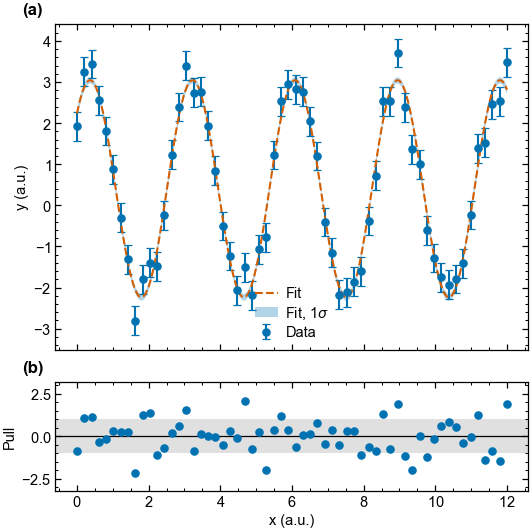

In [9]:
preview("elsevier")

fine = np.linspace(x.min(), x.max(), 500)

# Propagate the covariance by sampling: 500 parameter draws, then percentiles of the curves they give.
draws = rng.multivariate_normal(popt, pcov, 500)
curves = np.array([sinusoid(fine, *p) for p in draws])
lo, hi = np.percentile(curves, [15.9, 84.1], axis=0)      # central 68%, i.e. 1 sigma

pulls = residuals / y_err

fig, axs = jf.subplots("elsevier", 2, 1, width="single", ratio=1.0,
                       sharex=True, height_ratios=[3, 1])

axs[0].errorbar(x, y, yerr=y_err, linestyle="none", marker="o",
                capsize=plt.rcParams["errorbar.capsize"], label="Data")
axs[0].plot(fine, sinusoid(fine, *popt), label="Fit")
axs[0].fill_between(fine, lo, hi, alpha=0.3, linewidth=0, label=r"Fit, $1\sigma$")
axs[0].set_ylabel("y (a.u.)")
axs[0].legend()

axs[1].axhspan(-1, 1, color=jf.COLORS["black"], alpha=0.12, linewidth=0)
axs[1].axhline(0.0, linewidth=0.6, color=jf.COLORS["black"])
axs[1].plot(x, pulls, linestyle="none", marker="o")
axs[1].set_xlabel("x (a.u.)")
axs[1].set_ylabel("Pull")
axs[1].set_ylim(-3.2, 3.2)

jf.panel_labels(axs)
inside = np.mean(np.abs(pulls) <= 1) * 100
print(f"{inside:.0f}% of points fall within one sigma (about 68% expected)")
print("violations:", jf.check(fig, warn=False))

## Put the numbers on the figure

A fit is only useful if the reader can see what came out of it. Fold the parameters into the legend
label rather than floating them in a corner: the legend is placed by the layout engine, so it moves
with the data instead of colliding with it the first time the axis limits change.

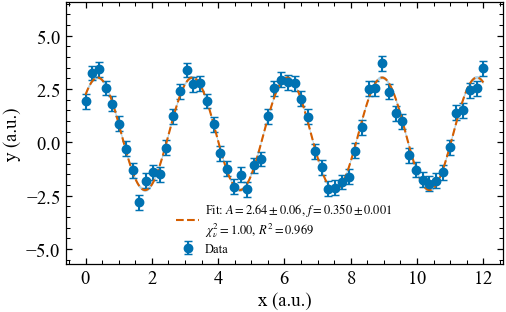

In [10]:
preview("aps")

fit_label = (f"Fit: $A = {popt[0]:.2f} \\pm {perr[0]:.2f}$, "
             f"$f = {popt[1]:.3f} \\pm {perr[1]:.3f}$\n"
             f"$\\chi^2_\\nu = {chi2_red:.2f}$, $R^2 = {r_squared:.3f}$")

fig, ax = jf.subplots("aps", width="single")
ax.errorbar(x, y, yerr=y_err, linestyle="none", marker="o",
            capsize=plt.rcParams["errorbar.capsize"], label="Data")
ax.plot(fine, sinusoid(fine, *popt), label=fit_label)
ax.fill_between(fine, lo, hi, alpha=0.3, linewidth=0)
ax.set_xlabel("x (a.u.)")
ax.set_ylabel("y (a.u.)")
ax.legend(loc="lower center", fontsize=6)
ax.margins(y=0.35)

Watch the font size when you put maths in a legend on a 7 pt theme: sub/superscripts render at 0.7x,
and `jf.check()` tells you when that falls below the publisher's floor.

In [11]:
violations = jf.check(fig, warn=False)
print(f"{len(violations)} violation(s)")
for violation in violations:
    print(" ", violation)

2 violation(s)
  [lettering] 'Fit: $A = 2.64 \\pm 0.06$, $f = 0.350 \\pm 0.001$\n$\\chi^2_\\nu = 1.00$, $R^2 = 0.969$' at 6.0 pt prints 1.46 mm tall, below the 2.0 mm minimum
  [lettering] 'Data' at 6.0 pt prints 1.46 mm tall, below the 2.0 mm minimum


## Save it

`jf.save()` writes PDF, SVG and PNG, runs `jf.check()` on the way past, and reports the size it wrote.

In [12]:
import tempfile

outdir = Path(tempfile.mkdtemp())
written = jf.save(fig, outdir / "fit_result")

print()
for path in written:
    print(f"  {path.name:22s} {path.stat().st_size / 1024:7.1f} kB")

/Users/achrafatila/Documents/Workflows/plotstyles/src/journalfig/_core.py:1010: JournalFigWarning: American Physical Society (PRB/PRL) figure requirements not met:
  [lettering] 'Fit: $A = 2.64 \\pm 0.06$, $f = 0.350 \\pm 0.001$\n$\\chi^2_\\nu = 1.00$, $R^2 = 0.969$' at 6.0 pt prints 1.46 mm tall, below the 2.0 mm minimum
  [lettering] 'Data' at 6.0 pt prints 1.46 mm tall, below the 2.0 mm minimum
  check(fig, journal=journal)


American Physical Society (PRB/PRL): 85.7 x 53.0 mm -> fit_result.pdf, fit_result.svg, fit_result.png



  fit_result.pdf            41.2 kB
  fit_result.svg            97.1 kB
  fit_result.png           144.7 kB


## Reproducing the data

The file records its own provenance, so nothing here depends on this notebook having been run in a
particular order. Regenerate it with:

```bash
python examples/data/make_oscillation.py
```

The seed is fixed, so the file that comes out is byte-identical to the one committed — which is what
makes the fitted parameters above reproducible rather than merely plausible.